### Imports
This cell imports necessary libraries: `make_regression` from `sklearn.datasets` for generating synthetic regression data, `matplotlib.pyplot` for plotting, and `numpy` for numerical operations.

In [48]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

### Generate Synthetic Data
This cell generates synthetic regression data using `make_regression` with 100 samples, 1 feature, and a noise level of 20.

In [49]:
X ,y = make_regression(n_samples= 100 , n_features= 1 , noise = 20 ,n_targets= 1)

### Visualize Data
This cell creates a scatter plot of the generated data points `X` and `y` to visualize their distribution.

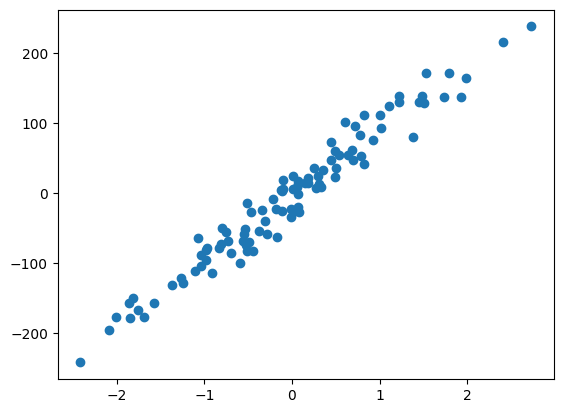

In [50]:
plt.scatter(X , y)
plt.show()

### Import Linear Regression
This cell imports the `LinearRegression` model from `sklearn.linear_model`.

In [51]:
from sklearn.linear_model import LinearRegression

### Instantiate Linear Regression Model
This cell initializes an instance of the `LinearRegression` model.

In [52]:
model = LinearRegression()

### Train Linear Regression Model
This cell fits the `LinearRegression` model to the data (`X` and `y`) and then prints the learned coefficients (`coef_`) and intercept (`intercept_`).

In [53]:
model.fit(X ,y)
print(model.coef_)
print(model.intercept_)

[92.24650133]
-3.1394932185509927


### Make Predictions and Import R2 Score
This cell imports the `r2_score` metric from `sklearn.metrics` and uses the trained `LinearRegression` model to make predictions (`y_pred`) on the input data `X`.

In [54]:
from sklearn.metrics import r2_score
y_pred = model.predict(X)

### Calculate R2 Score for Linear Regression
This cell calculates and prints the R-squared score, which measures how well the linear regression model fits the data.

In [55]:
r2_score(y , y_pred)

0.9564410305890487

### Custom Ridge Regression Implementation
This cell defines a custom `Ridge` regression class from scratch. It includes an `__init__` method for setting hyperparameters (learning rate, epochs, alpha), a `fit` method for training the model using stochastic gradient descent with L2 regularization, and a `predict` method for making predictions.

In [56]:
import numpy as np

class Ridge():
    def __init__(self, lr=0.01, epoch=1000, alpha=0.0001):
        self.coef_ = None
        self.intercept_ = None
        self.lr = lr
        self.epoch = epoch
        self.alpha = alpha

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0

        for _ in range(self.epoch):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            for i in indices:
                y_hat = self.intercept_ + np.dot(X[i], self.coef_)
                error = y[i] - y_hat

                db = -2 * error
                dw = -2 * error * X[i] + 2 * self.alpha * self.coef_

                self.intercept_ -= self.lr * db
                self.coef_ -= self.lr * dw

    def predict(self, X):
        return self.intercept_ + np.dot(X, self.coef_)

### Train Custom Ridge Regression Model
This cell instantiates the custom `Ridge` regression model with specified hyperparameters (learning rate, epochs, alpha). It then trains the model on the data (`X` and `y`) and prints the learned intercept and slope.

In [57]:
ridge_regression = Ridge(lr=0.5, epoch=10 , alpha= 0.0001)

ridge_regression.fit(X, y)

print("Intercept:", ridge_regression.intercept_)
print("Slope:", ridge_regression.coef_)

Intercept: 33.02302081250629
Slope: [101.92654943]


### Make Predictions with Custom Ridge Regression
This cell uses the trained custom `Ridge` regression model to make predictions (`y_pred_ridge`) on the input data `X`.

In [58]:
y_pred_ridge = ridge_regression.predict(X)

### Calculate R2 Score for Custom Ridge Regression
This cell calculates and prints the R-squared score for the custom Ridge regression model, indicating its fit to the data.

In [59]:
r2_score(y , y_pred_ridge)

0.8079637051561821

### Visualize All Predictions
This cell generates a scatter plot of the original data points and overlays the predictions from both the `LinearRegression` (red line) and the custom `Ridge` regression (green line) models for comparison.

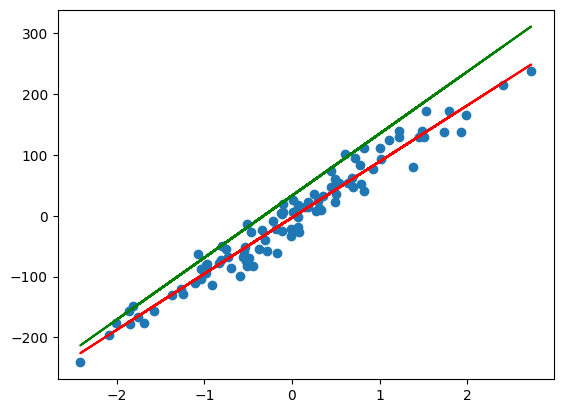

In [60]:
plt.scatter(X , y)
plt.plot(X , y_pred , color = "red")
plt.plot(X ,y_pred_ridge , color = "green")
plt.show()